In [49]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
from anndata import AnnData
import pathlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import skimage
import seaborn as sns
import tangram as tg



sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

%load_ext autoreload
%autoreload 2
#%matplotlib inline
%matplotlib notebook

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.26.4 scipy==1.14.0 pandas==2.2.2 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13
squidpy==1.5.0
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# checkout visium data using scanpy, squidpy packages, for reference see (https://scanpy-tutorials.readthedocs.io/en/latest/spatial/basic-analysis.html)

In [4]:
folder = '/data/runs/samples/Vis1_A1/outVis1_A1_210610/outs'


In [68]:
adata_st_test = sc.read_visium(path = folder, count_file='filtered_feature_bc_matrix.h5')

In [6]:
adata_st_test

AnnData object with n_obs × n_vars = 3529 × 27998
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [7]:
adata_st_test.obs

,in_tissue,array_row,array_col
AAACAACGAATAGTTC-1,1,0,16
AAACAAGTATCTCCCA-1,1,50,102
AAACAATCTACTAGCA-1,1,3,43
AAACACCAATAACTGC-1,1,59,19
AAACAGCTTTCAGAAG-1,1,43,9
...,...,...,...
TTGTTTCACATCCAGG-1,1,58,42
TTGTTTCATTAGTCTA-1,1,60,30
TTGTTTCCATACAACT-1,1,45,27
TTGTTTGTATTACACG-1,1,73,41


In [8]:
adata_st_test.var

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,mm10
Gm1992,ENSMUSG00000089699,Gene Expression,mm10
Gm37381,ENSMUSG00000102343,Gene Expression,mm10
Rp1,ENSMUSG00000025900,Gene Expression,mm10
Rp1,ENSMUSG00000109048,Gene Expression,mm10
...,...,...,...
AC168977.1,ENSMUSG00000079808,Gene Expression,mm10
PISD,ENSMUSG00000095041,Gene Expression,mm10
DHRSX,ENSMUSG00000063897,Gene Expression,mm10
Vmn2r122,ENSMUSG00000096730,Gene Expression,mm10


In [10]:
adata_st_test.obsm['spatial']

array([[ 847, 1762],
       [3553, 4428],
       [1011, 2600],
       ...,
       [3279, 2100],
       [4793, 2532],
       [1227, 2848]])

In [53]:
adata_st_test.obsm['spatial'].shape

(3529, 2)

In [85]:
#check where positions were mapped on to tissue 
adata_st_test.obs['thing'] = 'a'


In [71]:
adata_st_test.var_names_make_unique()

In [72]:
adata_st_test

AnnData object with n_obs × n_vars = 3529 × 27998
    obs: 'in_tissue', 'array_row', 'array_col', 'thing'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'thing_colors'
    obsm: 'spatial'

In [13]:
adata_st_test.var

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,mm10
Gm1992,ENSMUSG00000089699,Gene Expression,mm10
Gm37381,ENSMUSG00000102343,Gene Expression,mm10
Rp1,ENSMUSG00000025900,Gene Expression,mm10
Rp1-1,ENSMUSG00000109048,Gene Expression,mm10
...,...,...,...
AC168977.1,ENSMUSG00000079808,Gene Expression,mm10
PISD,ENSMUSG00000095041,Gene Expression,mm10
DHRSX,ENSMUSG00000063897,Gene Expression,mm10
Vmn2r122,ENSMUSG00000096730,Gene Expression,mm10


In [73]:
adata_st_test.var["mt"] = adata_st_test.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata_st_test, qc_vars=["mt"], inplace=True)

In [74]:
#check to make sure 'pct_counts_mt' are actual values, not zero
adata_st_test.obs

,in_tissue,array_row,array_col,thing,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACAACGAATAGTTC-1,1,0,16,a,4870,8.491055,14428.0,9.576996,24.189077,29.685334,37.004436,50.242584,2197.0,7.695303,15.227336
AAACAAGTATCTCCCA-1,1,50,102,a,2373,7.772332,5057.0,8.528727,32.687364,38.263793,45.699031,59.422583,1160.0,7.057037,22.938499
AAACAATCTACTAGCA-1,1,3,43,a,2557,7.846981,4825.0,8.481773,20.082902,26.487047,35.150259,50.901554,472.0,6.159095,9.782384
AAACACCAATAACTGC-1,1,59,19,a,3701,8.216628,9667.0,9.176577,25.892211,31.716148,39.722768,53.832626,1563.0,7.355002,16.168407
AAACAGCTTTCAGAAG-1,1,43,9,a,4988,8.514991,14997.0,9.615672,24.518237,29.792625,36.787357,49.283190,2431.0,7.796469,16.209909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTTCACATCCAGG-1,1,58,42,a,2750,7.919720,6639.0,8.800867,30.667269,36.978461,45.564091,59.783100,1029.0,6.937314,15.499322
TTGTTTCATTAGTCTA-1,1,60,30,a,2833,7.949444,6375.0,8.760296,25.113725,31.498039,40.439216,55.858824,932.0,6.838405,14.619608
TTGTTTCCATACAACT-1,1,45,27,a,3220,8.077447,9131.0,9.119540,33.326032,39.196145,47.201840,60.519111,1924.0,7.562681,21.071075
TTGTTTGTATTACACG-1,1,73,41,a,3137,8.051341,7091.0,8.866723,28.571429,34.762375,42.490481,55.859540,909.0,6.813445,12.819067


In [16]:
adata_st_test

AnnData object with n_obs × n_vars = 3529 × 27998
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'

<IPython.core.display.Javascript object>


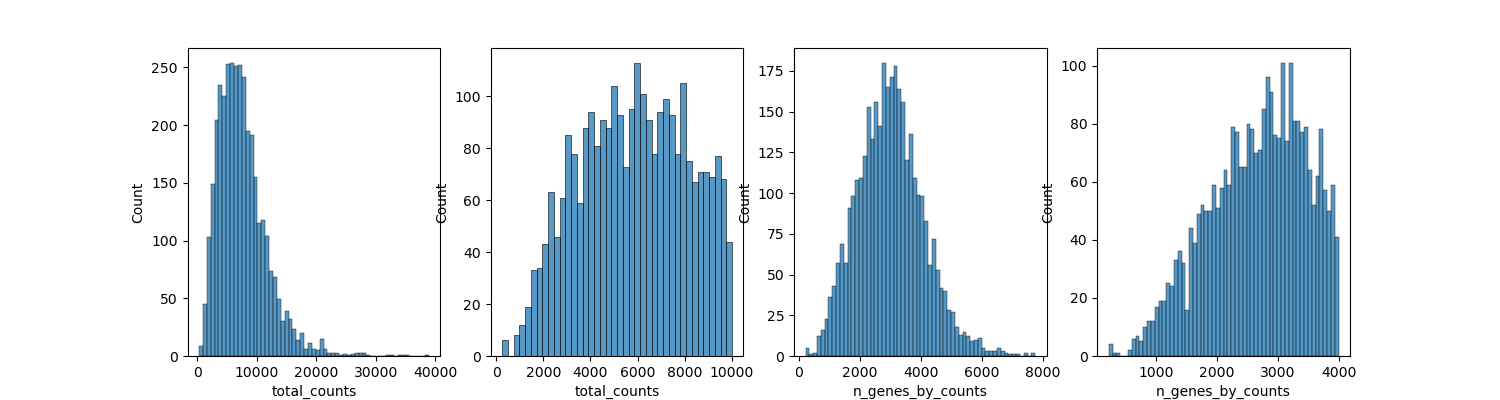

In [75]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata_st_test.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(
    adata_st_test.obs["total_counts"][adata_st_test.obs["total_counts"] < 10000],
    kde=False,
    bins=40,
    ax=axs[1],
)
sns.histplot(adata_st_test.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(
    adata_st_test.obs["n_genes_by_counts"][adata_st_test.obs["n_genes_by_counts"] < 4000],
    kde=False,
    bins=60,
    ax=axs[3],
)
plt.show()

<IPython.core.display.Javascript object>


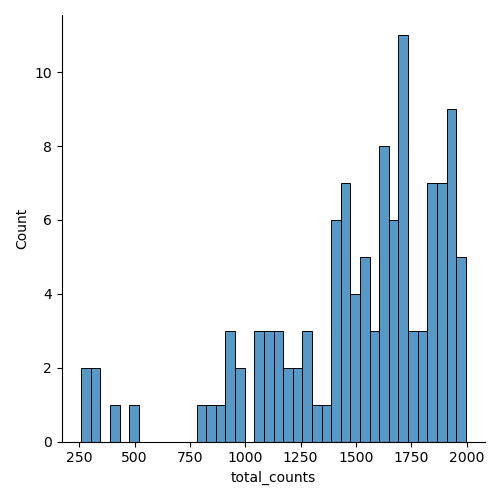

In [76]:
sns.displot(adata_st_test.obs['total_counts'][adata_st_test.obs["total_counts"]<2000],kde = False, bins = 40)

In [77]:
sc.pp.filter_cells(adata_st_test, min_counts=1100)
sc.pp.filter_cells(adata_st_test, max_counts=20000)


<IPython.core.display.Javascript object>


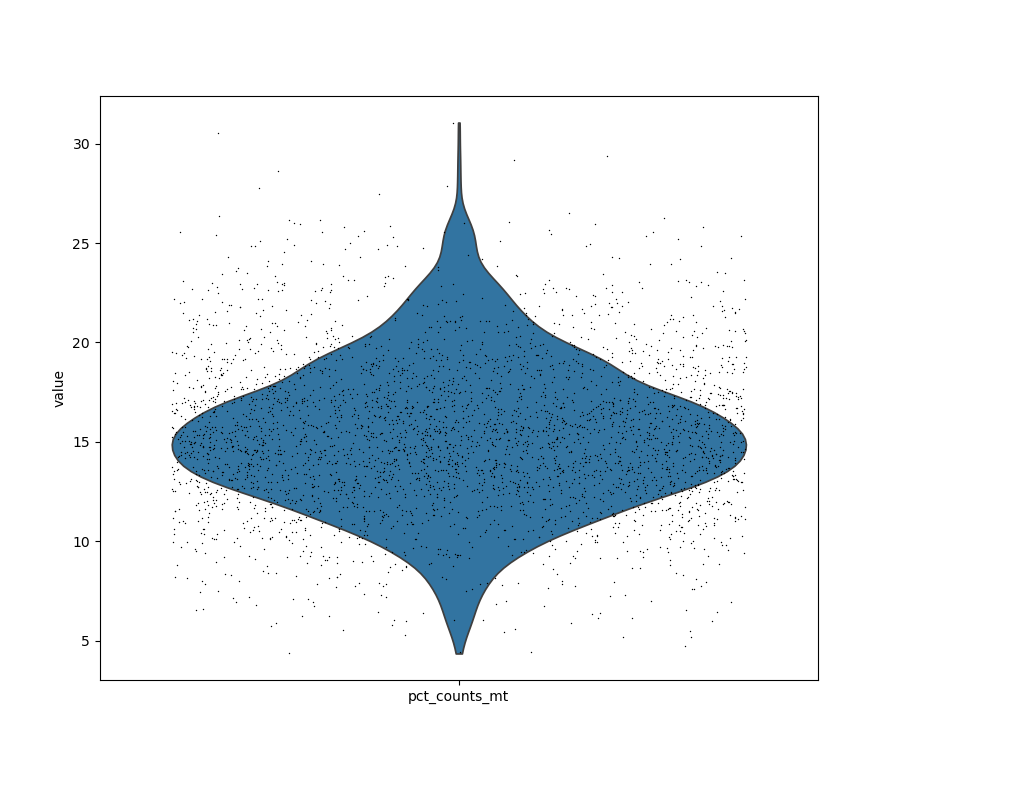

In [78]:
sc.pl.violin(adata_st_test,['pct_counts_mt'],jitter = 0.4)

In [79]:
adata_st_test

AnnData object with n_obs × n_vars = 3453 × 27998
    obs: 'in_tissue', 'array_row', 'array_col', 'thing', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial', 'thing_colors'
    obsm: 'spatial'

In [80]:
adata_st_test = adata_st_test[adata_st_test.obs["pct_counts_mt"] < 20].copy()
print(f"#cells after MT filter: {adata_st_test.n_obs}")
sc.pp.filter_genes(adata_st_test, min_cells=10)

#cells after MT filter: 3093


In [81]:
adata_st_test

AnnData object with n_obs × n_vars = 3093 × 15091
    obs: 'in_tissue', 'array_row', 'array_col', 'thing', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatial', 'thing_colors'
    obsm: 'spatial'

In [70]:
#pre filtering
plt.rcParams["figure.figsize"] = (8,8)
sc.pl.spatial(adata_st_test, color='thing')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


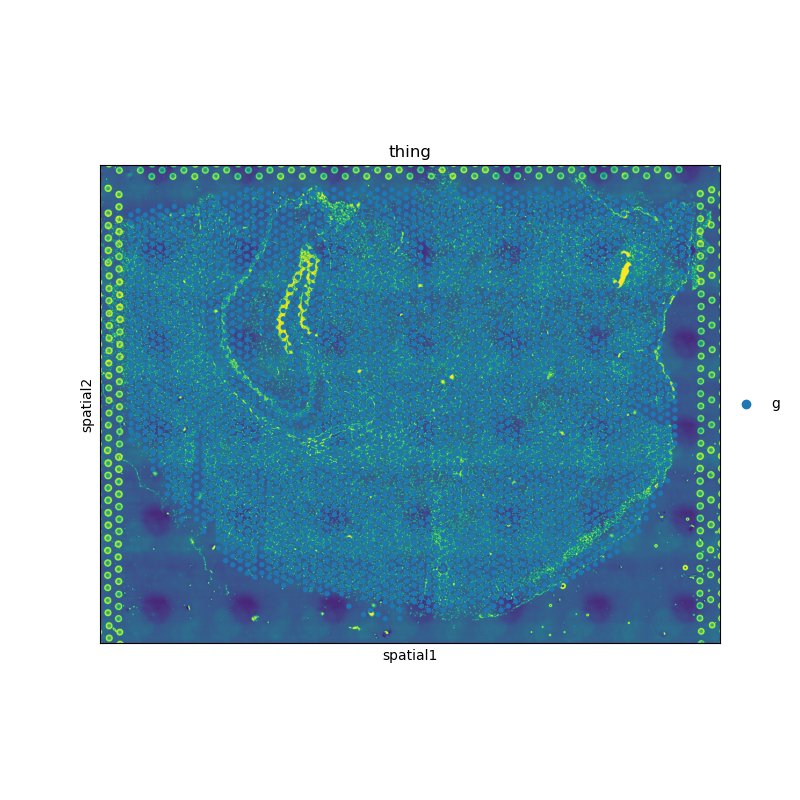

In [84]:
#post filtering
plt.rcParams["figure.figsize"] = (8,8)
sc.pl.spatial(adata_st_test, color='thing')

In [86]:
sc.pp.normalize_total(adata_st_test, inplace=True)
sc.pp.log1p(adata_st_test)
sc.pp.highly_variable_genes(adata_st_test, flavor="seurat", n_top_genes=2000)

In [23]:
adata_st_test

AnnData object with n_obs × n_vars = 2495 × 15081
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial'

In [87]:
sc.pp.pca(adata_st_test)
sc.pp.neighbors(adata_st_test)
sc.tl.umap(adata_st_test)
sc.tl.leiden(
    adata_st_test, key_added="clusters", flavor="igraph", directed=False, n_iterations=2
)

<IPython.core.display.Javascript object>


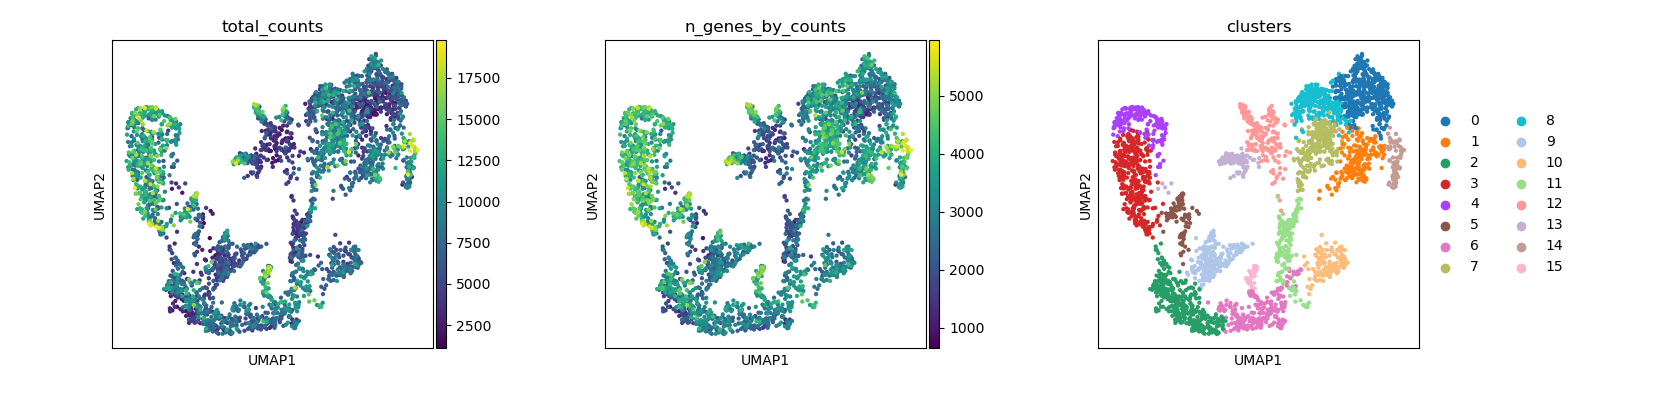

In [88]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata_st_test, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

<IPython.core.display.Javascript object>


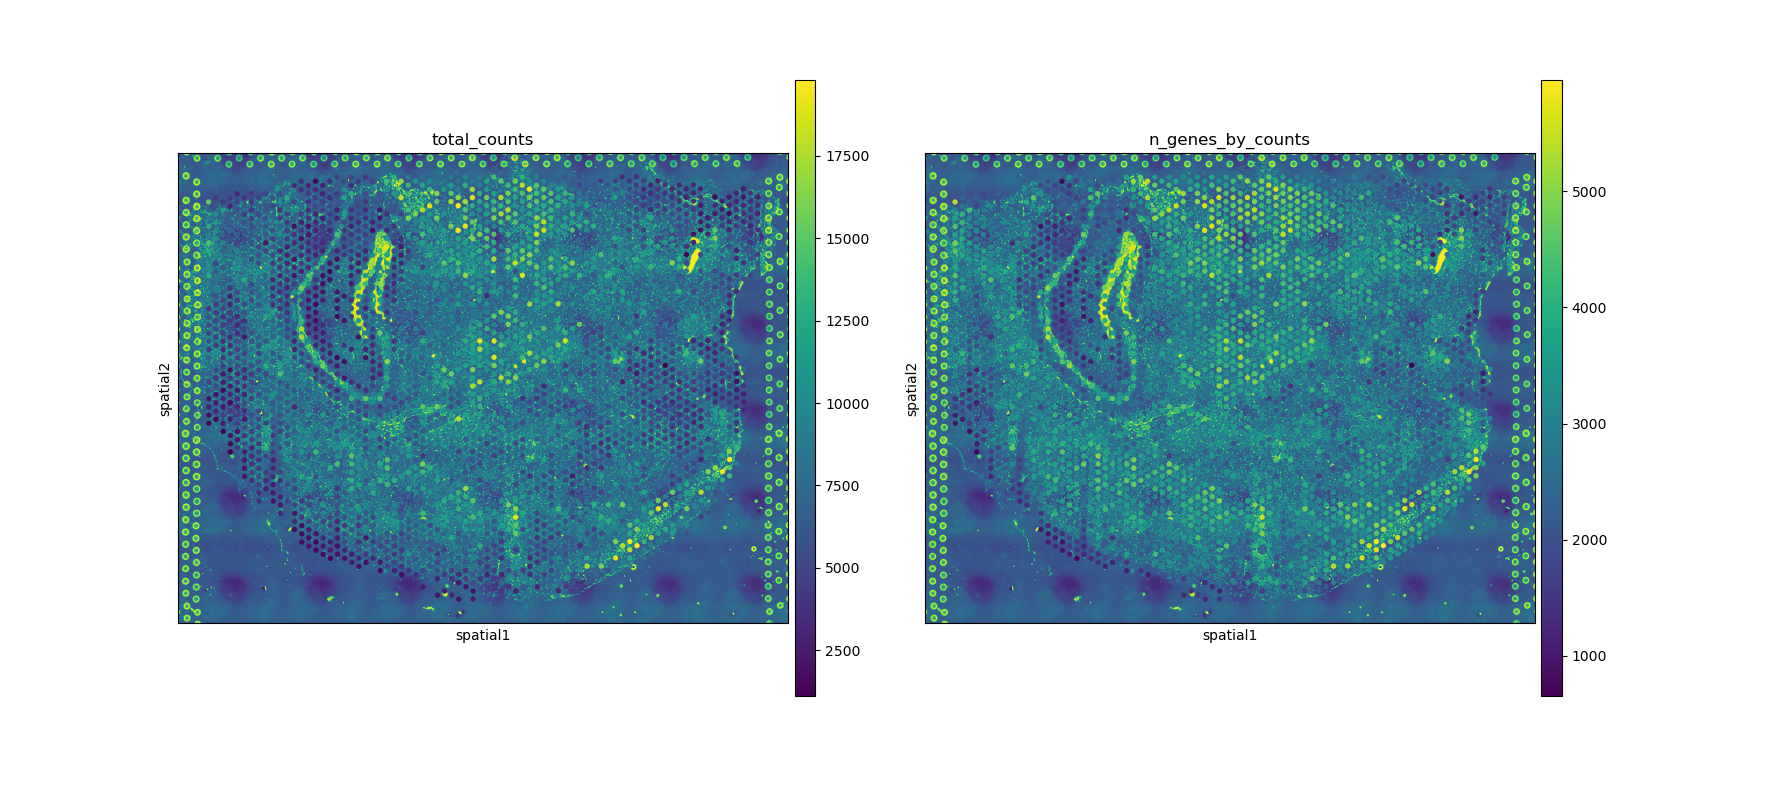

In [91]:
plt.rcParams["figure.figsize"] = (8,8)
sc.pl.spatial(adata_st_test, img_key="hires", color = ["total_counts","n_genes_by_counts"])

In [27]:
adata_st_test

AnnData object with n_obs × n_vars = 2495 × 15081
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'clusters', 'clusters_colors'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

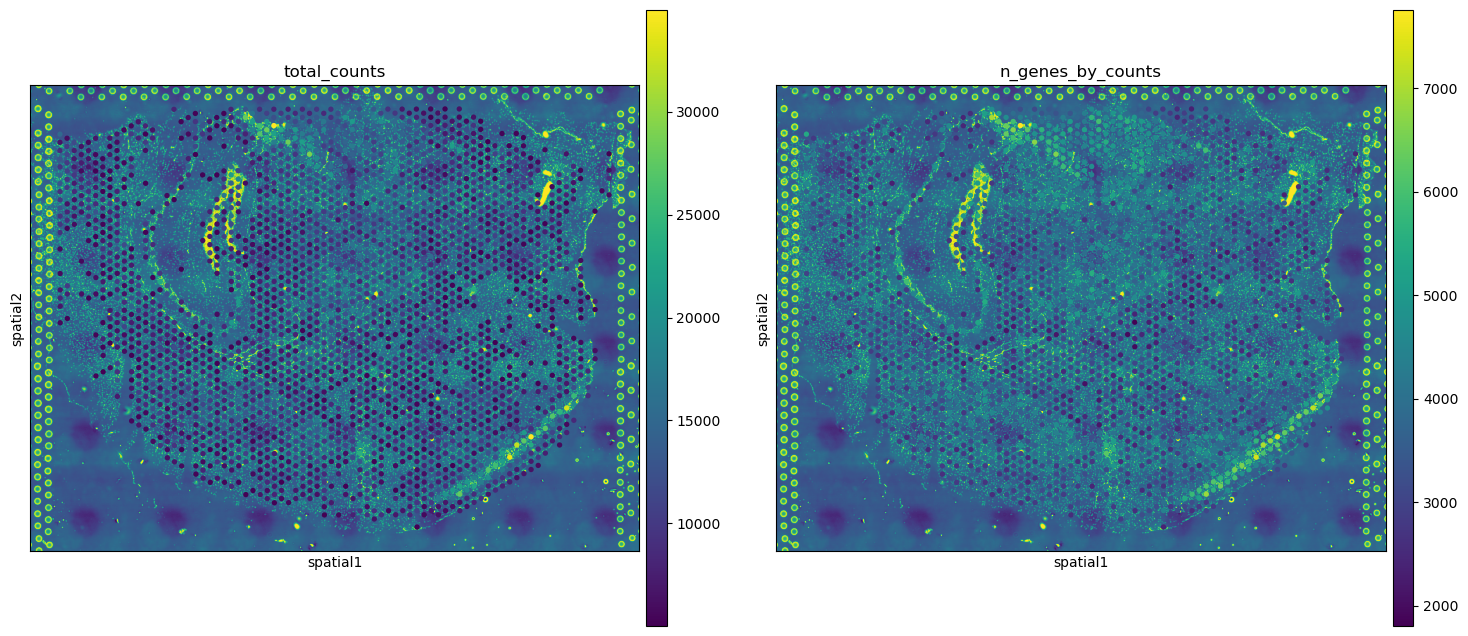

In [28]:
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(adata_st_test, img_key="hires", color=["total_counts", "n_genes_by_counts"])

<IPython.core.display.Javascript object>


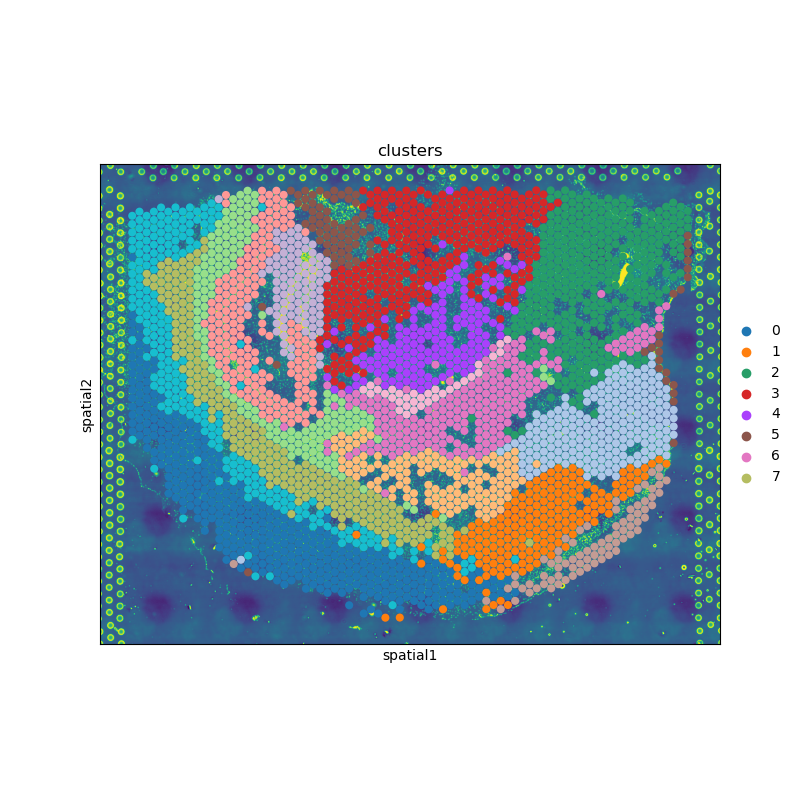

In [92]:
sc.pl.spatial(adata_st_test, img_key="hires", color="clusters", size=1.5)

In [248]:
adata_st_test.uns['spatial']['outVis1_A1_210610']['images']['lowres'].shape

(600, 600)

In [245]:
adata_st_test.uns['spatial']

{'outVis1_A1_210610': {'images': {'hires': array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
           1.        ],
          [1.        , 1.        , 1.        , ..., 0.9996643 , 0.99964905,
           0.9996643 ],
          [1.        , 1.        , 1.        , ..., 0.7380026 , 0.73223466,
           0.73344016],
          ...,
          [1.        , 1.        , 1.        , ..., 0.39580378, 0.40817884,
           0.39649042],
          [1.        , 1.        , 1.        , ..., 0.40241092, 0.41329062,
           0.42020294],
          [1.        , 1.        , 1.        , ..., 0.42716107, 0.4422217 ,
           0.4428626 ]], dtype=float32),
   'lowres': array([[0.99536127, 0.88485545, 0.83849853, ..., 0.8162051 , 0.8181277 ,
           0.8220645 ],
          [0.9819333 , 0.5568475 , 0.38448158, ..., 0.30525672, 0.31303883,
           0.3238575 ],
          [0.98069733, 0.52729076, 0.33838406, ..., 0.27354848, 0.27681392,
           0.29068437],
          ...,
   

In [103]:
adata_st_test.obsm['spatial'].shape

(3093, 2)

In [108]:
adata_st_test.obsm['spatial'][:,0]

array([ 847, 1011, 4036, ..., 4090, 4793, 1227])

<IPython.core.display.Javascript object>


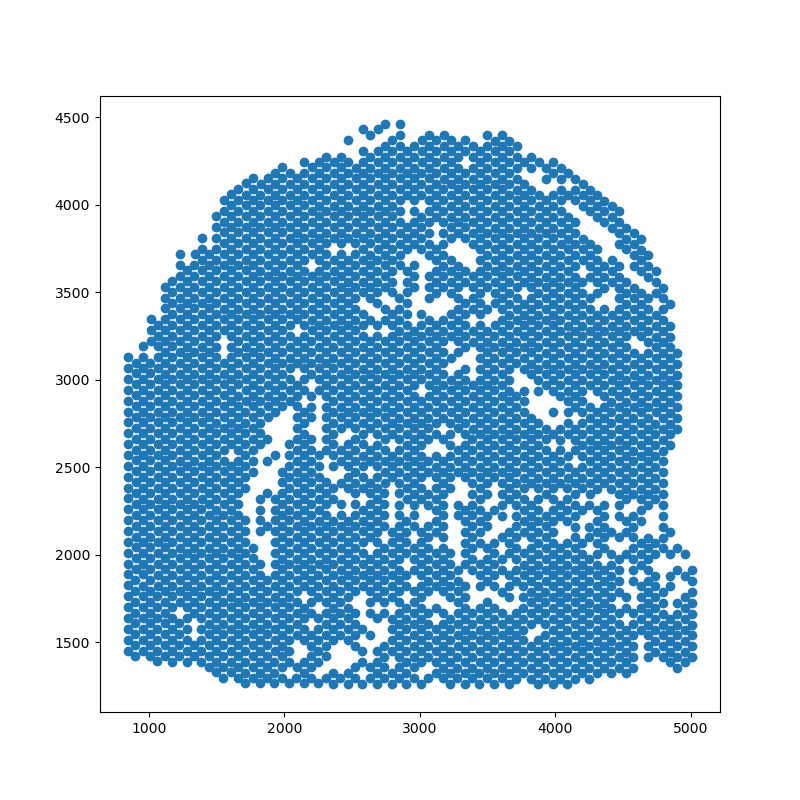

In [178]:
fig, ax = plt.subplots()
ax.scatter(adata_st_test.obsm['spatial'][:,0], adata_st_test.obsm['spatial'][:,1])
plt.show()

In [179]:
mask = adata_st_test.obsm['spatial'].astype('bool')

In [180]:
mask = np.invert(mask)

In [159]:
np.where(adata_st_test.obsm['spatial'][:,0]>3000)

(array([   2,    3,    4, ..., 3089, 3090, 3091]),)

In [160]:
np.where(adata_st_test.obsm['spatial'][:,1]>3000)

(array([   9,   11,   13, ..., 3084, 3086, 3088]),)

In [181]:
mask[np.where(adata_st_test.obsm['spatial'][:,0]>3000),0] = True

In [182]:
mask[np.where(adata_st_test.obsm['spatial'][:,1]>3000),1] = True

In [183]:
mask = mask[:, 0] & mask[:, 1]

In [184]:
mask = np.array([mask, mask]).T

<IPython.core.display.Javascript object>


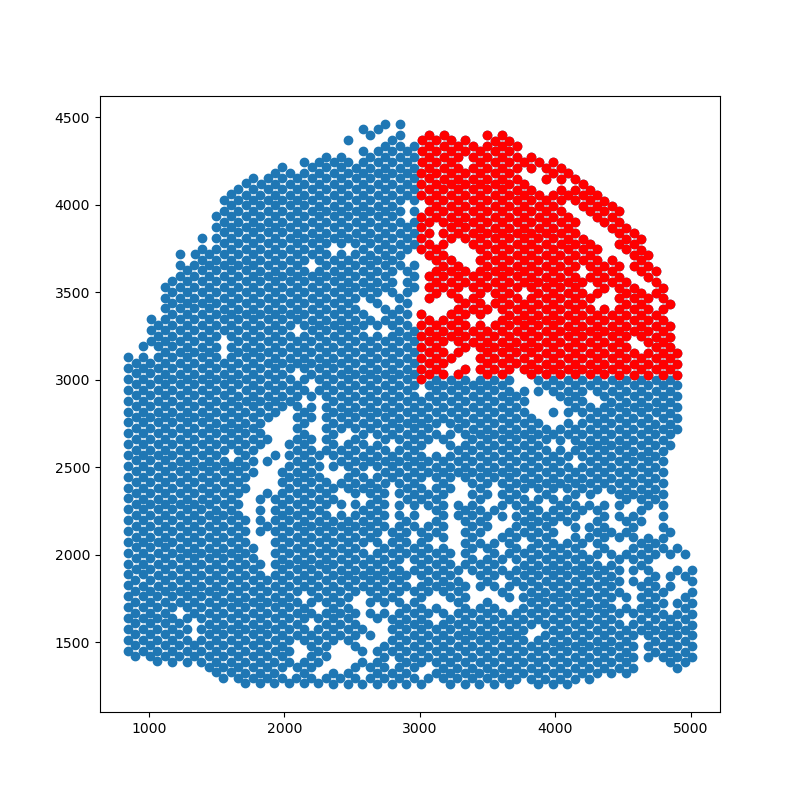

In [186]:
fig, ax = plt.subplots()
ax.scatter(adata_st_test.obsm['spatial'][:,0], adata_st_test.obsm['spatial'][:,1])
ax.scatter(adata_st_test.obsm['spatial'][np.where(mask[:,0]==True),0], adata_st_test.obsm['spatial'][np.where(mask[:,0]==True),1], c = 'r')
plt.show()

In [198]:
adata_st_test.obs

,in_tissue,array_row,array_col,thing,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_counts,clusters
AAACAACGAATAGTTC-1,1,0,16,a,4870,8.491055,14428.0,9.576996,24.189077,29.685334,37.004436,50.242584,2197.0,7.695303,15.227336,14428.0,0
AAACAATCTACTAGCA-1,1,3,43,a,2557,7.846981,4825.0,8.481773,20.082902,26.487047,35.150259,50.901554,472.0,6.159095,9.782384,4825.0,0
AAACACCAATAACTGC-1,1,59,19,a,3701,8.216628,9667.0,9.176577,25.892211,31.716148,39.722768,53.832626,1563.0,7.355002,16.168407,9667.0,2
AAACAGCTTTCAGAAG-1,1,43,9,a,4988,8.514991,14997.0,9.615672,24.518237,29.792625,36.787357,49.283190,2431.0,7.796469,16.209909,14997.0,3
AAACAGGGTCTATATT-1,1,47,13,a,5486,8.610137,18443.0,9.822495,22.377054,27.983517,35.319633,48.690560,2328.0,7.753194,12.622675,18443.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,1,31,77,a,4022,8.299783,10501.0,9.259321,20.578992,26.426055,34.739549,49.871441,1076.0,6.981935,10.246643,10501.0,7
TTGTTTCACATCCAGG-1,1,58,42,a,2750,7.919720,6639.0,8.800867,30.667269,36.978461,45.564091,59.783100,1029.0,6.937314,15.499322,6639.0,6
TTGTTTCATTAGTCTA-1,1,60,30,a,2833,7.949444,6375.0,8.760296,25.113725,31.498039,40.439216,55.858824,932.0,6.838405,14.619608,6375.0,2
TTGTTTGTATTACACG-1,1,73,41,a,3137,8.051341,7091.0,8.866723,28.571429,34.762375,42.490481,55.859540,909.0,6.813445,12.819067,7091.0,5


In [210]:
adata_st_test.obs[mask[:,0]]

,in_tissue,array_row,array_col,thing,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_counts,clusters
AAACGGTTGCGAACTG-1,1,67,59,a,2361,7.767264,4689.0,8.453188,25.634464,31.819151,39.987204,55.384943,731.0,6.595780,15.589678,4689.0,9
AAACTGCTGGCTCCAA-1,1,45,67,a,3441,8.143808,8806.0,9.083302,29.150579,35.180559,42.857143,56.109471,1551.0,7.347300,17.612991,8806.0,10
AAAGTGTGATTTATCT-1,1,44,94,a,3657,8.204672,8879.0,9.091557,20.970830,27.480572,35.803581,50.658858,794.0,6.678342,8.942449,8879.0,0
AAAGTTGACTCCCGTA-1,1,42,96,a,2421,7.792349,4844.0,8.485703,23.554913,29.995871,38.645747,54.438481,538.0,6.289716,11.106524,4844.0,0
AAATACCTATAAGCAT-1,1,47,69,a,4260,8.357259,12032.0,9.395409,26.304854,32.164229,39.727394,53.100066,1846.0,7.521318,15.342421,12032.0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGGGAAGACGAGCCG-1,1,68,64,a,1931,7.566311,3798.0,8.242494,30.437072,36.703528,45.339652,61.716693,698.0,6.549651,18.378094,3798.0,9
TTGTGAACCTAATCCG-1,1,56,90,a,4155,8.332308,10497.0,9.258940,21.510908,26.960084,34.609889,48.823473,1292.0,7.164721,12.308279,10497.0,1
TTGTGCAGCCACGTCA-1,1,60,74,a,2896,7.971431,6202.0,8.732788,23.202193,29.377620,37.745888,53.369881,865.0,6.763885,13.947114,6202.0,1
TTGTGTATGCCACCAA-1,1,56,60,a,2464,7.809947,4806.0,8.477828,22.992093,29.026217,37.473991,52.913025,557.0,6.324359,11.589680,4806.0,9


In [215]:
adata_st_test.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 9485749 stored elements and shape (3093, 15091)>

In [214]:
adata_st_test.X[mask[:,0],:]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1857184 stored elements and shape (582, 15091)>

In [218]:
adata_st_test.var

,gene_ids,feature_types,genome,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
Xkr4,ENSMUSG00000051951,Gene Expression,mm10,False,71,0.020686,0.020475,97.988099,73.0,4.304065,64,False,0.019991,0.343601,0.554285
Sox17,ENSMUSG00000025902,Gene Expression,mm10,False,115,0.034004,0.033439,96.741286,120.0,4.795791,103,True,0.037429,0.442513,1.119040
Mrpl15,ENSMUSG00000033845,Gene Expression,mm10,False,1061,0.383678,0.324745,69.934826,1354.0,7.211557,946,False,0.310186,0.225739,-0.319722
Lypla1,ENSMUSG00000025903,Gene Expression,mm10,False,704,0.240578,0.215577,80.051006,849.0,6.745236,631,False,0.194832,0.193089,-0.305088
Tcea1,ENSMUSG00000033813,Gene Expression,mm10,False,1498,0.619439,0.482080,57.551714,2186.0,7.690286,1342,False,0.451928,0.163058,-0.681228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Spry3,ENSMUSG00000061654,Gene Expression,mm10,False,192,0.058373,0.056733,94.559365,206.0,5.332719,171,False,0.053205,0.296634,0.286122
Tmlhe,ENSMUSG00000079834,Gene Expression,mm10,False,15,0.004250,0.004241,99.574950,15.0,2.772589,12,True,0.004009,0.513542,1.524590
PISD,ENSMUSG00000095041,Gene Expression,mm10,False,2039,1.100312,0.742086,42.221593,3883.0,8.264621,1839,False,0.726759,0.405308,0.349649
DHRSX,ENSMUSG00000063897,Gene Expression,mm10,False,273,0.084160,0.080805,92.264097,297.0,5.697093,239,False,0.075381,0.287935,0.236450


In [235]:
adata_st_test.obsm['spatial'][mask[:,0]]

array([[4470, 3092],
       [3281, 3342],
       [3229, 4180],
       ...,
       [4092, 3558],
       [3875, 3123],
       [3605, 3093]])

In [236]:
np.mean(adata_st_test.obsm['spatial'][mask[:,0]], axis=0)

array([3825.23367698, 3620.0652921 ])

In [226]:
#get subset version using mask
adata_st_test_subset = sc.AnnData(adata_st_test.X[mask[:,0],:],adata_st_test.obs[mask[:,0]],adata_st_test.var)

In [227]:
adata_st_test_subset

AnnData object with n_obs × n_vars = 582 × 15091
    obs: 'in_tissue', 'array_row', 'array_col', 'thing', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

In [238]:
#add updated spatial coords
adata_st_test_subset.obsm['spatial'] = adata_st_test.obsm['spatial'][mask[:,0]]

In [239]:
adata_st_test_subset.obsm['spatial']

array([[4470, 3092],
       [3281, 3342],
       [3229, 4180],
       ...,
       [4092, 3558],
       [3875, 3123],
       [3605, 3093]])

In [252]:
adata_st_test.uns['spatial']

{'outVis1_A1_210610': {'images': {'hires': array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
           1.        ],
          [1.        , 1.        , 1.        , ..., 0.9996643 , 0.99964905,
           0.9996643 ],
          [1.        , 1.        , 1.        , ..., 0.7380026 , 0.73223466,
           0.73344016],
          ...,
          [1.        , 1.        , 1.        , ..., 0.39580378, 0.40817884,
           0.39649042],
          [1.        , 1.        , 1.        , ..., 0.40241092, 0.41329062,
           0.42020294],
          [1.        , 1.        , 1.        , ..., 0.42716107, 0.4422217 ,
           0.4428626 ]], dtype=float32),
   'lowres': array([[0.99536127, 0.88485545, 0.83849853, ..., 0.8162051 , 0.8181277 ,
           0.8220645 ],
          [0.9819333 , 0.5568475 , 0.38448158, ..., 0.30525672, 0.31303883,
           0.3238575 ],
          [0.98069733, 0.52729076, 0.33838406, ..., 0.27354848, 0.27681392,
           0.29068437],
          ...,
   

In [249]:
#add Scale Factor from adata_st_test.uns['spatial']
adata_st_test_subset.uns['spatial'] = adata_st_test.uns['spatial']

In [250]:
adata_st_test_subset

AnnData object with n_obs × n_vars = 582 × 15091
    obs: 'in_tissue', 'array_row', 'array_col', 'thing', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial'
    obsm: 'spatial'

In [93]:
#write to file

In [94]:
pwd

'/home/isaac/analysis/scRNA-seq'

In [95]:
output_path = '/bigdata/isaac/tangram_integration/'
adata_st_test.write(output_path +'adata_st_test.h5ad', compression='gzip')

In [251]:
output_path = '/bigdata/isaac/tangram_integration/'
adata_st_test_subset.write(output_path +'adata_st_test_subset.h5ad', compression='gzip')

# checkout tiff file(s)

Test image - tissue processing flow

In [43]:
img = sq.datasets.visium_fluo_image_crop()

In [44]:
type(img)

squidpy.im._container.ImageContainer

In [45]:
img

ImageContainer[shape=(7272, 7272), layers=['image']]

In [14]:
img['image']

<xarray.DataArray 'image' (y: 7272, x: 7272, z: 1, channels: 3)> Size: 317MB
dask.array<transpose, shape=(7272, 7272, 1, 3), dtype=uint16, chunksize=(7272, 7272, 1, 3), chunktype=numpy.ndarray>
Coordinates:
  * z        (z) <U38 152B 'V1_Adult_Mouse_Brain_Coronal_Section_2'
Dimensions without coordinates: y, x, channels

In [34]:
img_processed = img.copy()

In [35]:
sq.im.process(img=img_processed, layer="image", method="smooth")
sq.im.segment(
    img=img_processed,
    layer="image_smooth",
    method="watershed",
    channel=0,
)

<IPython.core.display.Javascript object>


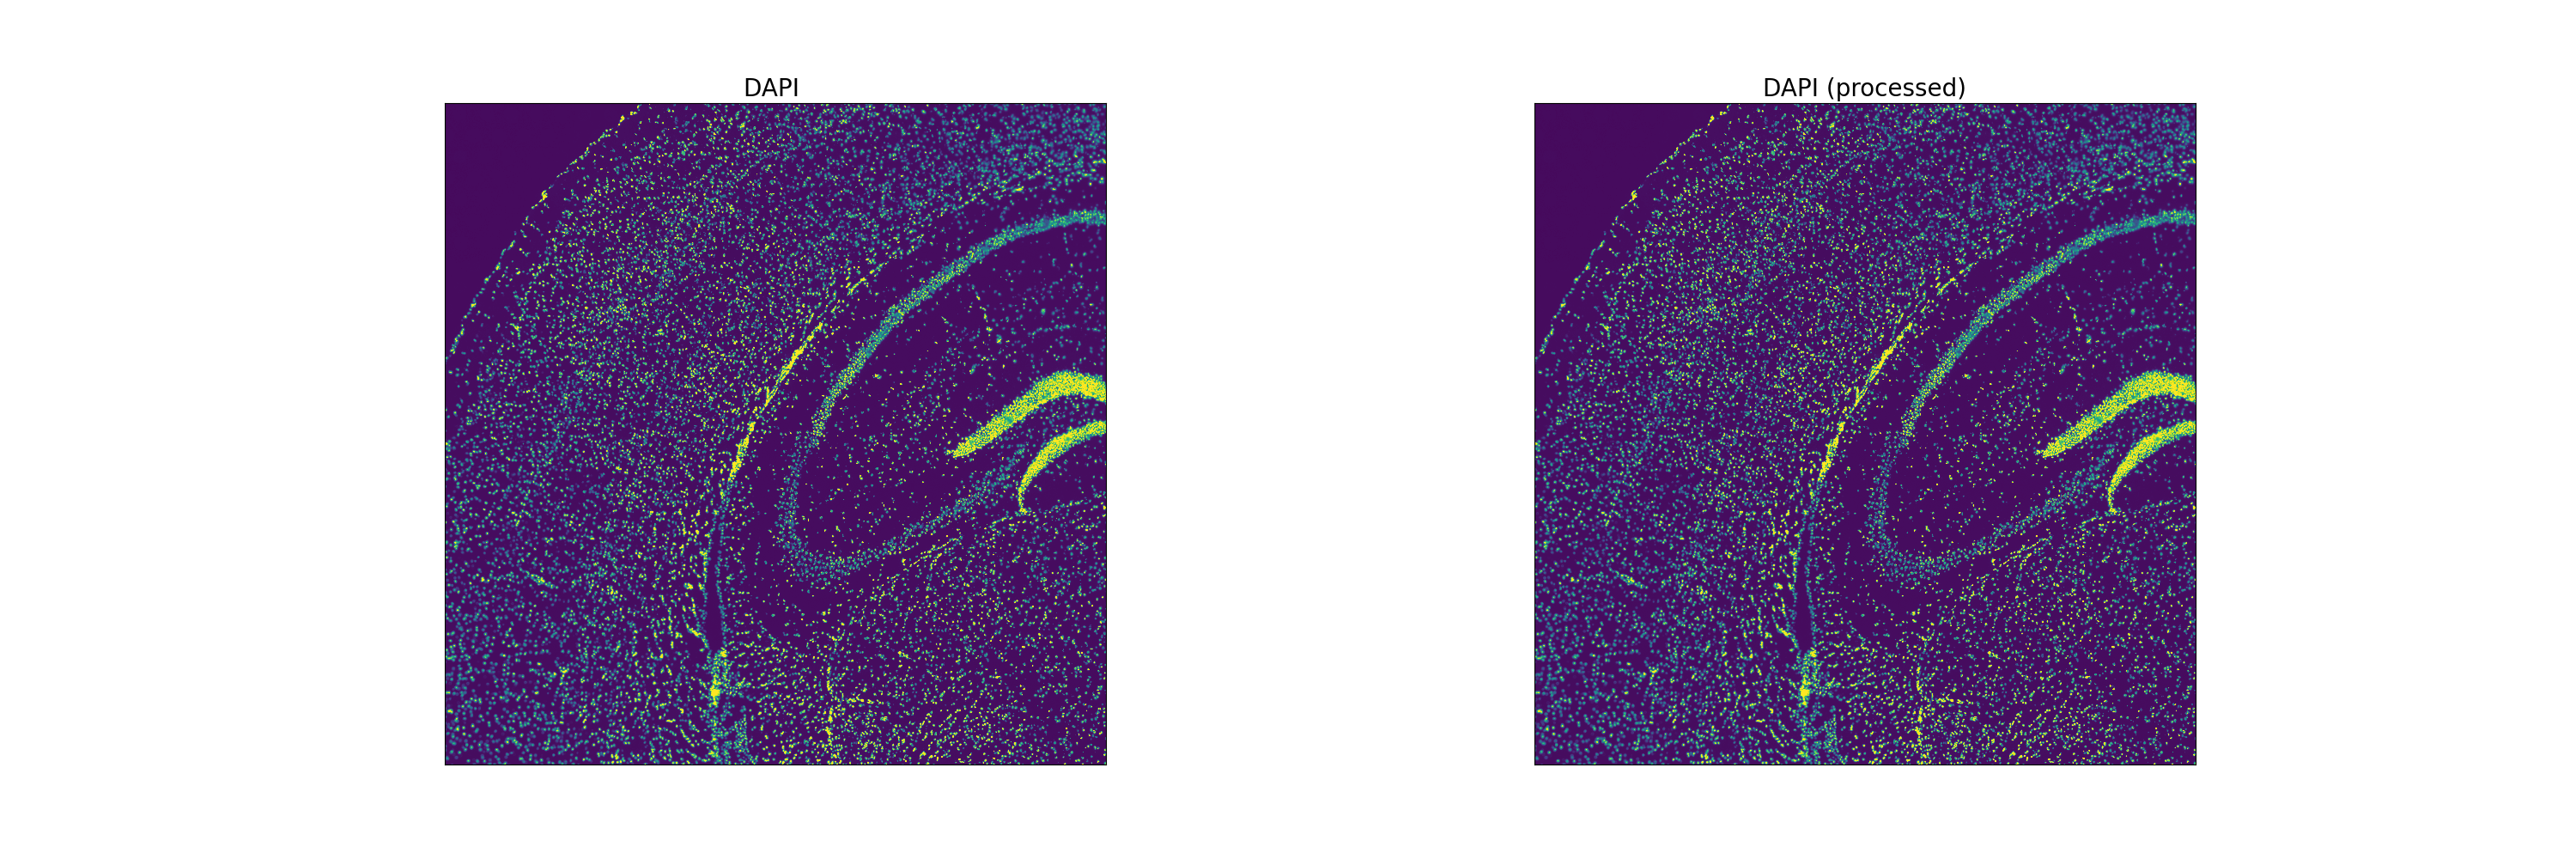

In [52]:
inset_y = 1500
inset_x = 1700
inset_sy = 400
inset_sx = 500

fig, axs = plt.subplots(1,2,figsize=(30, 10))
axs[0].imshow(
    img["image"][:,:, 0, 0]
    / 65536,
    interpolation="none",
)
axs[0].grid(False)
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title("DAPI ", fontdict={"fontsize": 20})

axs[1].imshow(
    img_processed["image"][:,:, 0, 0]
    / 65536,
    interpolation="none",
)
axs[1].grid(False)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title("DAPI (processed)", fontdict={"fontsize": 20})

plt.show()

In [17]:
zoomed_img = img["image"][inset_y : inset_y + inset_sy, inset_x : inset_x + inset_sx, 0, 0]/ 65536

In [18]:
img["image"].shape

(7272, 7272, 1, 3)

In [19]:
zoomed_img.shape

(400, 500)

In [20]:
#try loading tiff image from sample
img_folder = '/data/runs/samples/Vis1_A1/'
img_vis1_a1 = sq.datasets.visium_hne_image(img_folder + 'Vis1_A1.tif')

In [21]:
img_vis1_a1['image']

<xarray.DataArray 'image' (y: 11757, x: 11291, z: 1, channels: 3)> Size: 398MB
dask.array<transpose, shape=(11757, 11291, 1, 3), dtype=uint8, chunksize=(11757, 11291, 1, 3), chunktype=numpy.ndarray>
Coordinates:
  * z        (z) <U20 80B 'V1_Adult_Mouse_Brain'
Dimensions without coordinates: y, x, channels

In [22]:
img_folder = '/data/runs/samples/Vis1_A1/'
img_vis1_a1_gray = sq.datasets.visium_hne_image(img_folder + 'Vis1_A1_gray.tif')

In [23]:
img_vis1_a1_gray["image"]

<xarray.DataArray 'image' (y: 11757, x: 11291, z: 1, channels: 3)> Size: 398MB
dask.array<transpose, shape=(11757, 11291, 1, 3), dtype=uint8, chunksize=(11757, 11291, 1, 3), chunktype=numpy.ndarray>
Coordinates:
  * z        (z) <U20 80B 'V1_Adult_Mouse_Brain'
Dimensions without coordinates: y, x, channels

<IPython.core.display.Javascript object>


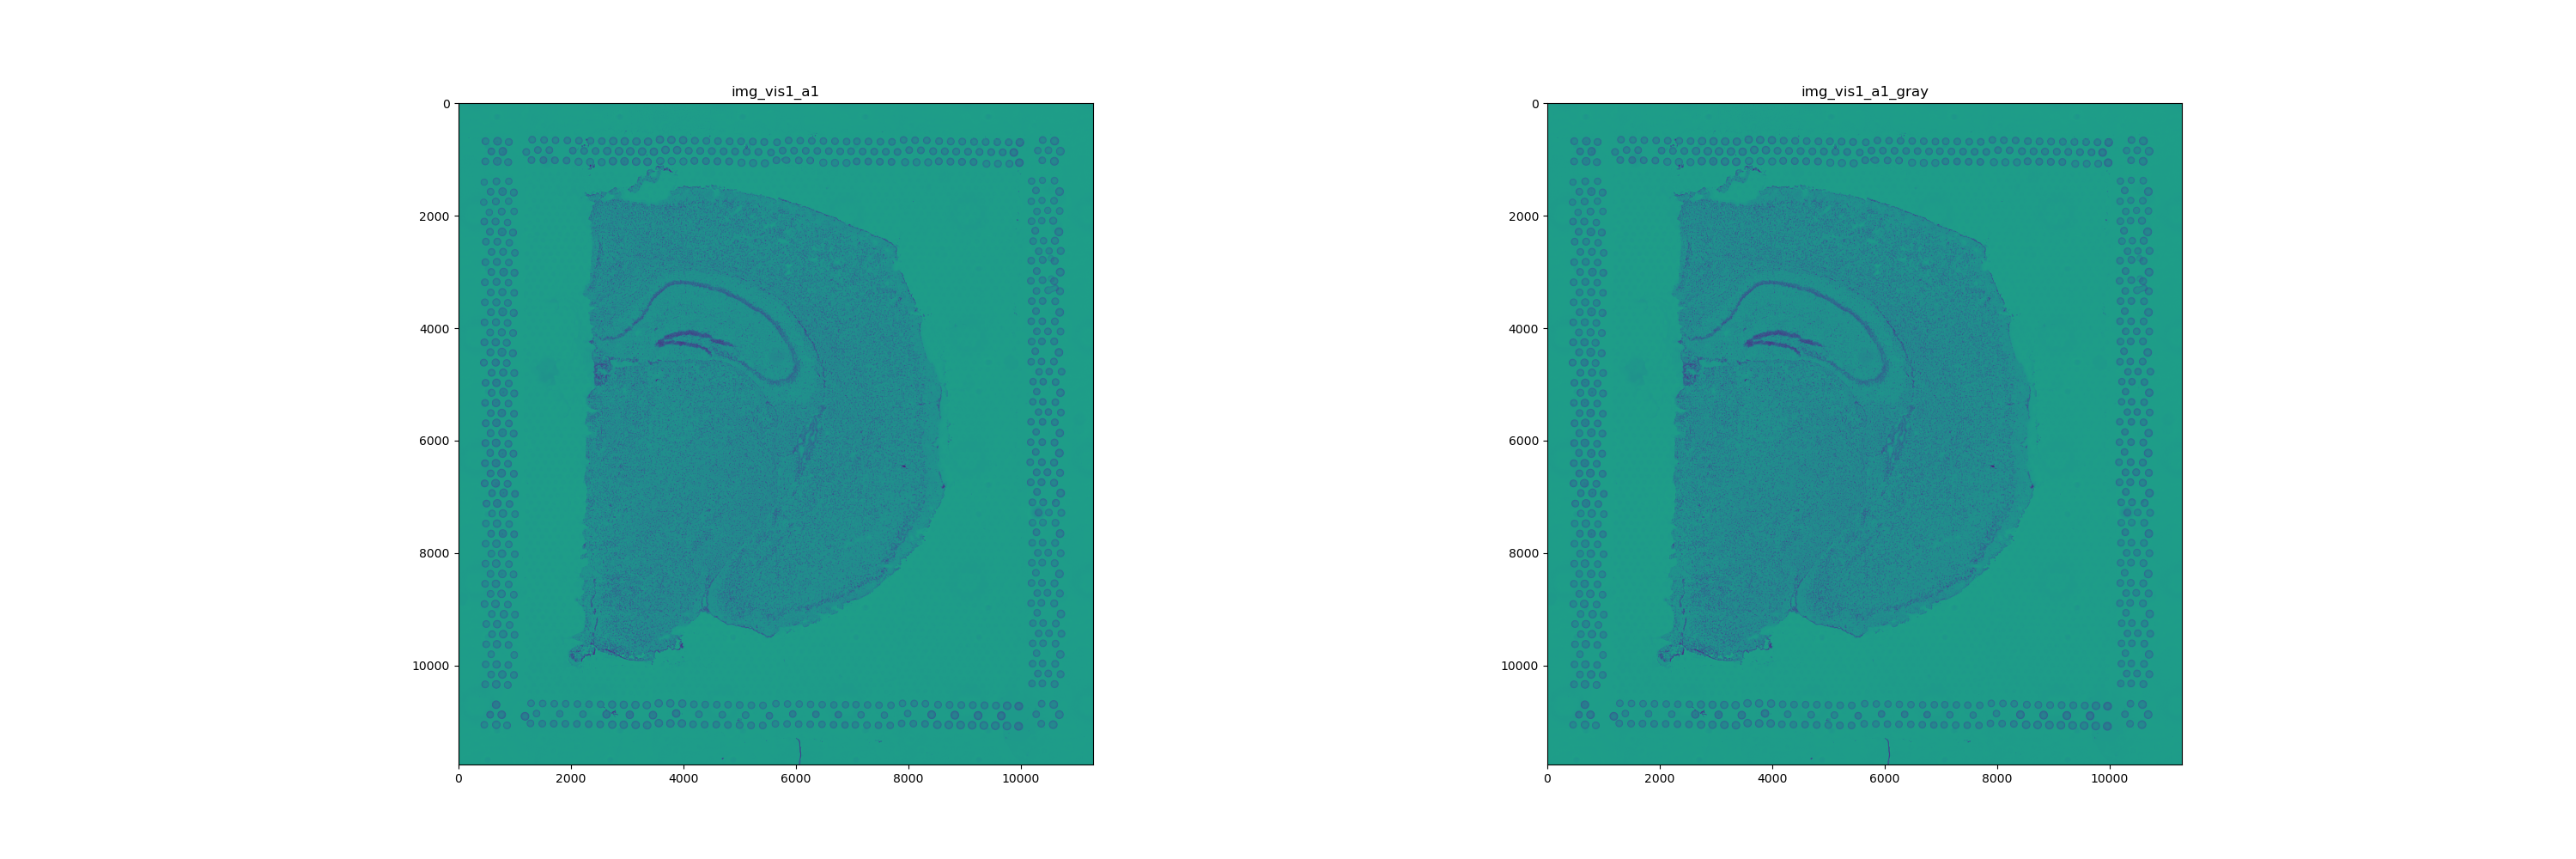

In [188]:
fig,axs = plt.subplots(1,2, figsize = (30,10))
axs[0].imshow(img_vis1_a1['image'][:,:, 0, 0])
axs[0].set_title('img_vis1_a1')
axs[1].imshow(img_vis1_a1_gray['image'][:,:, 0, 0])
axs[1].set_title('img_vis1_a1_gray')
plt.show()

No apparent difference between _a1 and _a1_gray...

Do Image Processing and compare with original

In [25]:
img_vis1_a1_processed = img_vis1_a1.copy()

In [189]:
sq.im.process(img=img_vis1_a1_processed, layer="image", method="smooth")
sq.im.segment(
    img=img_vis1_a1_processed,
    layer="image_smooth",
    method="watershed",
    channel=0,
)

<IPython.core.display.Javascript object>


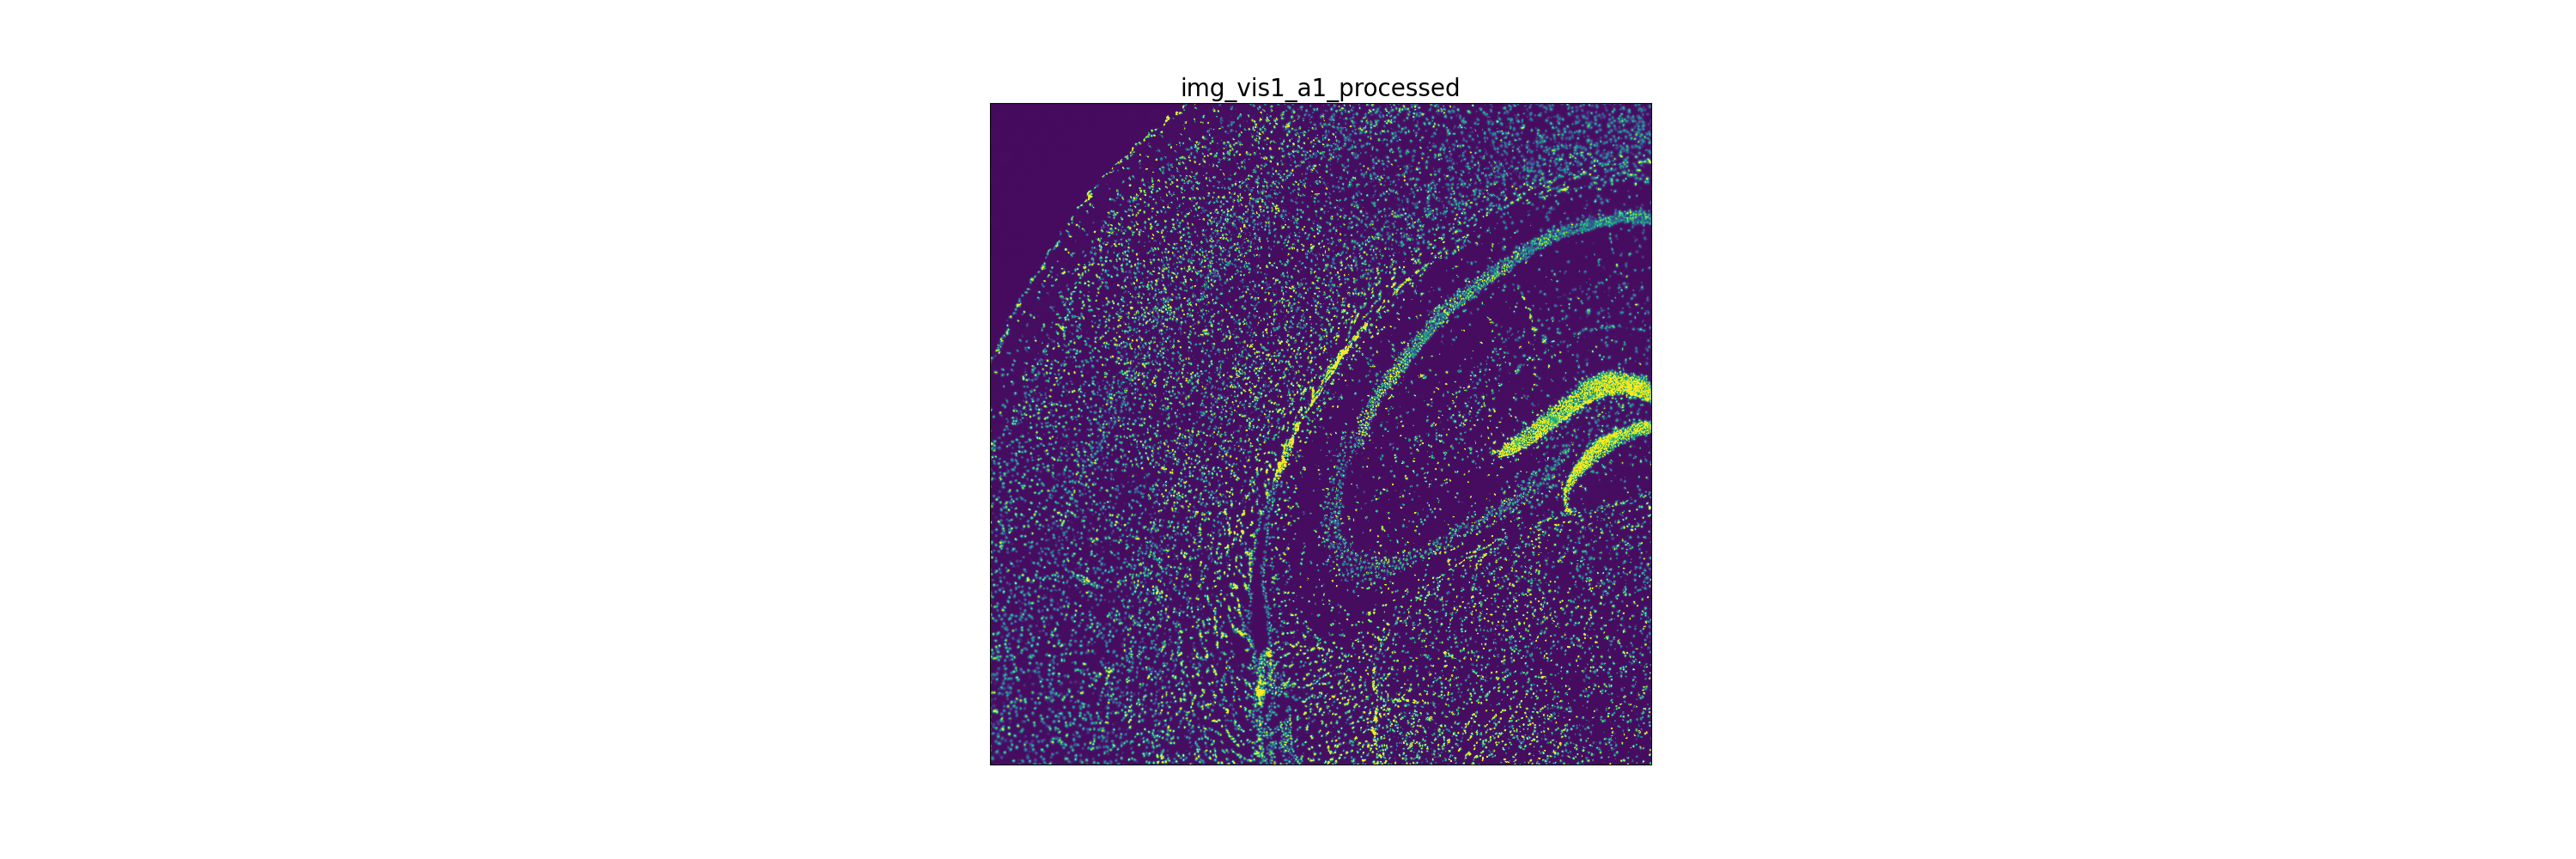

In [190]:
fig, axs = plt.subplots(figsize=(30, 10))

axs.imshow(
    img["image"][:,:, 0, 0],
    interpolation="none",
)
axs.grid(False)
axs.set_xticks([])
axs.set_yticks([])
axs.set_title("img_vis1_a1_processed", fontdict={"fontsize": 20})

plt.show()